# 1.  Objetivos da aula
Ao final desta aula, você será capaz de:

Ler arquivos CSV com parâmetros importantes (sep, encoding, usecols, nrows).
Ler arquivos Excel com abas diferentes usando sheet_name.
Entender a ideia de ler dados de banco de dados (SQL) e APIs, mesmo que de forma introdutória.
Salvar DataFrames em CSV e Excel para reutilizar depois.
Fazer leituras “sob medida”, sem precisar carregar tudo de uma vez.

# 2. Por que se preocupar com leitura de dados?
Na teoria tudo é bonitinho: pd.read_csv("arquivo.csv") e acabou. Na prática:

O arquivo vem com separador estranho (; ou \t).
O arquivo foi salvo com encoding diferente (UTF-8, ISO-8859-1…).
Você não quer carregar todas as colunas (arquivo gigante).
Você quer ler apenas algumas linhas pra testar.
Saber usar bem as opções do read_csv e read_excel é o que te tira do “iniciante travado em erro” pro “data analyst que resolve a treta rapidinho”.

# 3. read_csv na vida real
3.1. CSV mais comum (separado por vírgula)
Exemplo de arquivo vendas.csv:

order_id,customer_id,data_pedido,valor,cidade
1,101,2024-10-01,200.0,Juiz de Fora
2,102,2024-10-01,150.0,São Paulo
3,103,2024-10-02,900.0,Rio de Janeiro

In [ ]:
import pandas as pd

df = pd.read_csv("vendas.csv")
print(df.head())
print(df.dtypes)

# 3.2. Quando o separador não é vírgula (sep)
Em muitos arquivos brasileiros, o separador é ;

order_id;customer_id;data_pedido;valor;cidade
1;101;2024-10-01;200.0;Juiz de Fora
2;102;2024-10-01;150.0;São Paulo
3;103;2024-10-02;900.0;Rio de Janeiro

Se você fizer read_csv sem ajustar, vai virar uma coluna só.

# Para arrumar, use sep:

In [ ]:
df = pd.read_csv("vendas_ponto_virgula.csv", sep=";")
print(df.head())

# 3.3. Encoding: acentos e caracteres estranhos

Se ao ler o CSV aparecer erro de encoding ou caracteres estranhos (tipo Ã, §), provavelmente o arquivo não está em utf-8. Exemplos comuns:

utf-8
latin-1
ISO-8859-1


In [ ]:
# Você pode testar assim:

df = pd.read_csv("vendas.csv", sep=";", encoding="latin-1")

# ou

df = pd.read_csv("vendas.csv", sep=";", encoding="ISO-8859-1")

se der erro de encoding, tente latin-1 ou ISO-8859-1, que geralmente resolvem para arquivos antigos/Windows.

# 3.4. Lendo apenas algumas colunas (usecols)

Se o arquivo tem 50 colunas, mas você só precisa de 3, não faz sentido carregar tudo. Use usecols:

In [ ]:
df_pequeno = pd.read_csv("vendas.csv",usecols=["order_id", "valor", "cidade"])
df_pequeno.head

# 3.5. Lendo apenas algumas linhas (nrows)

Às vezes o arquivo tem milhões de linhas e você só quer olhar uma amostra para entender o formato.

nrows=10 → lê apenas as 10 primeiras linhas. Depois que você testar e entender o arquivo, você lê “pra valer”.

In [ ]:
df_amostra = pd.read_csv("vendas.csv", nrows=10)
df_amostra

# 4.1. Salvando em CSV

* index=False → não salva a coluna do índice no arquivo.
* encoding="utf-8" → bom padrão para compatibilidade.

In [ ]:
df_pequeno.to_csv("vendas_filtrado.csv", index=False, encoding="utf-8")

# 4.2. Salvando em Excel

In [ ]:
df_pequeno.to_excel("vendas_filtrado.xlsx", index=False)

# 5. Lendo planilhas Excel com read_excel

Muitas empresas usam planilhas Excel para tudo: RH, financeiro, estoque, etc.

# 5.1. Lendo uma única aba

Suponha que você tem um arquivo rh_empresa.xlsx com a aba colaboradores: Colunas:

nome
setor
salario

In [ ]:
df_colab = pd.read_excel("rh_empresa.xlsx", sheet_name="colaboradores")
print(df_colab.head())

# Se você não passar sheet_name, o pandas geralmente lê a primeira aba por padrão

# 5.2. Lendo uma aba diferente

Se no mesmo arquivo você tem outra aba, por exemplo setores: 
Colunas:
setor
gestor
Você lê assim:

In [ ]:
df_setores = pd.read_excel("rh_empresa.xlsx", sheet_name="setores")
print(df_setores.head())

Você pode depois fazer merge entre esses DataFrames (mais pra frente no módulo).

# 5.3. Lendo várias abas de uma vez (noção rápida)

Você pode passar uma lista em sheet_name e o pandas devolve um dicionário de DataFrames:


In [ ]:
abas = pd.read_excel("rh_empresa.xlsx", sheet_name=["colaboradores", "setores"])
type(abas)

Isso vira algo como:

dict

E você acessa assim:

In [ ]:
df_colab = abas["colaboradores"]
df_setores = abas["setores"]

Não precisa ir fundo nisso agora, é só pra você saber que existe.

# Noção rápida: leitura de SQL e APIs

## 6.1. Lendo de um banco SQL (conceito)

Na prática, muitos dados moram em bancos de dados (MySQL, PostgreSQL, SQL Server, SQLite…). O fluxo geral é:

Usar uma biblioteca (ex.: sqlalchemy ou sqlite3) para criar uma conexão com o banco.
Escrever uma query SQL (ex.: SELECT * FROM vendas).
Passar essa conexão + query para o pandas.read_sql.
Exemplo conceitual (não se preocupe se não rodar agora):

In [ ]:
import sqlite3
import pandas as pd

con = sqlite3.connect("meu_banco.db")

df_sql = pd.read_sql("SELECT * FROM vendas", con)
df_sql.head()

Na sua cabeça, guardamos a ideia:

“Dá pra puxar dados direto do banco pro pandas, sem precisar exportar CSV”.

## 6.2. Lendo de APIs (conceito)

Você já viu isso no módulo de APIs, mas aqui a ideia é:

* Usar requests pra fazer uma requisição.
* Pegar o JSON da resposta.
* Criar um DataFrame.

Exemplo rápido:

In [1]:
import requests
import pandas as pd

url = "https://jsonplaceholder.typicode.com/posts"
res = requests.get(url)
dados = res.json()           # lista de dicionários
df_api = pd.DataFrame(dados)
df_api.head()

,userId,id,title,body
0,1,1,sunt aut facere repellat provident occaecati e...,quia et suscipit\nsuscipit recusandae consequu...
1,1,2,qui est esse,est rerum tempore vitae\nsequi sint nihil repr...
2,1,3,ea molestias quasi exercitationem repellat qui...,et iusto sed quo iure\nvoluptatem occaecati om...
3,1,4,eum et est occaecati,ullam et saepe reiciendis voluptatem adipisci\...
4,1,5,nesciunt quas odio,repudiandae veniam quaerat sunt sed\nalias aut...


A moral é:

A origem dos dados pode ser CSV, Excel, Banco ou API. No fim, o seu ponto de partida no pandas é sempre o DataFrame.

# 7. Resumo da aula

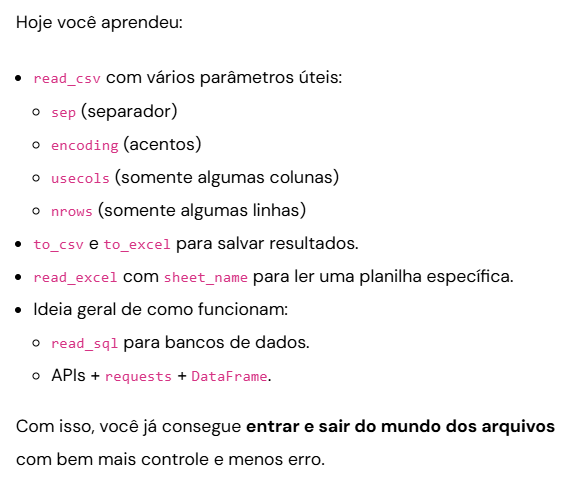